In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful!")

Setup successful!


Load Dataset

In [123]:
df = pd.read_csv("../data/ai4i2020.csv")

print(df.head())

print("Dataset shape:", df.shape)
print(df.columns.tolist())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [124]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [126]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [127]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [128]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [129]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [130]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

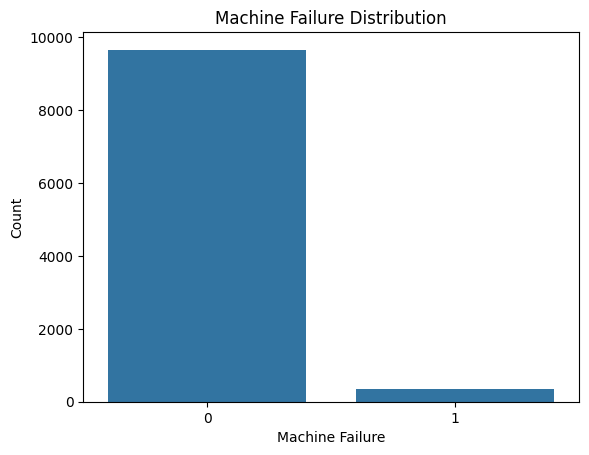

In [131]:
sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

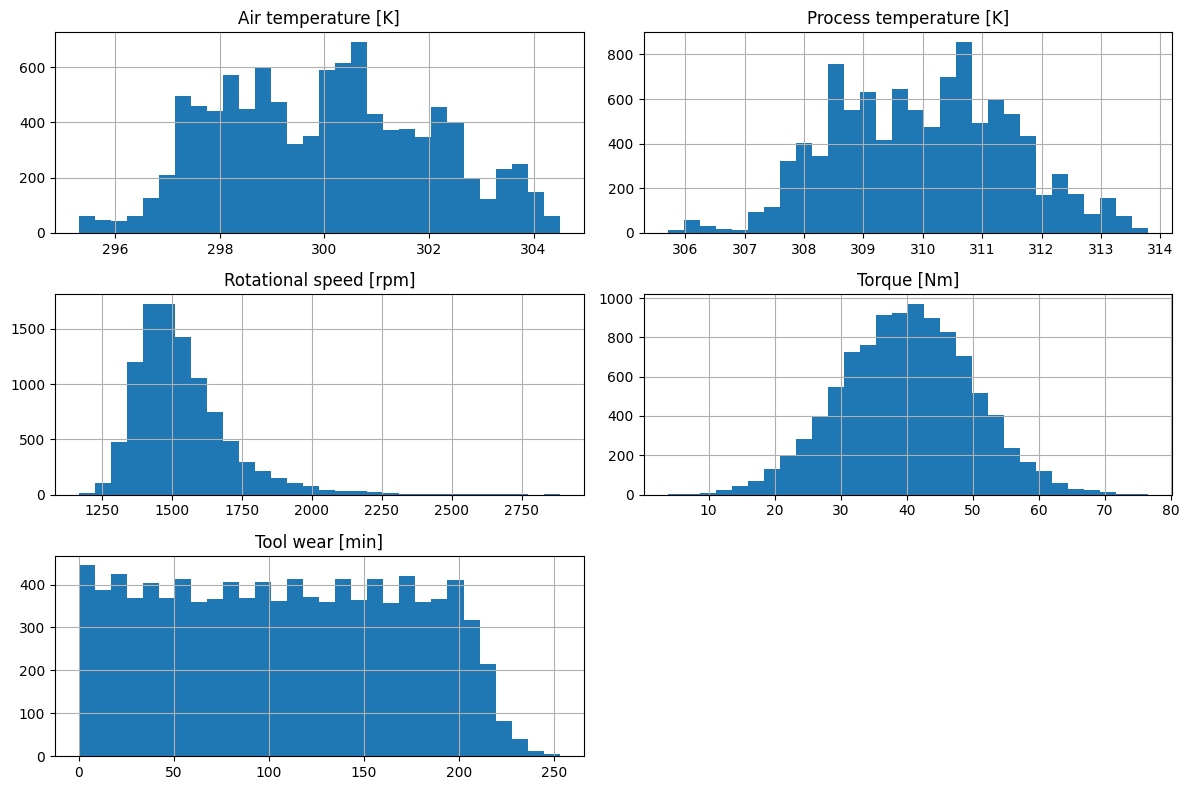

In [132]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[features].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

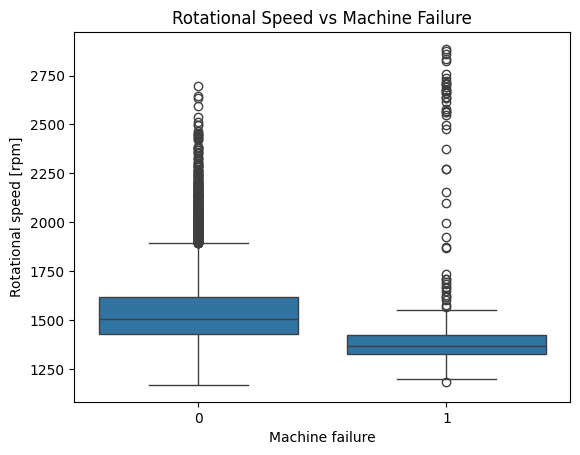

In [133]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Rotational speed [rpm]"
)

plt.title("Rotational Speed vs Machine Failure")
plt.show()

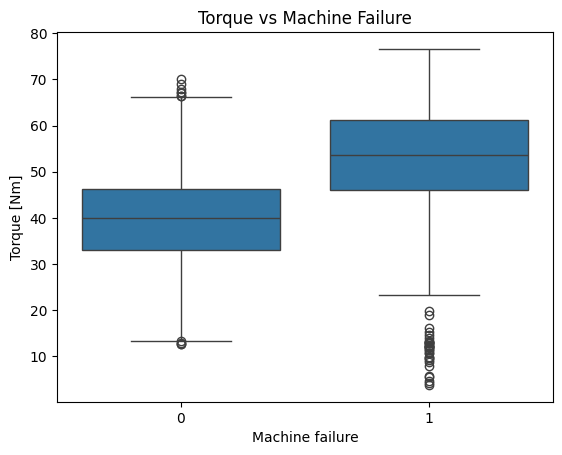

In [134]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque [Nm]"
)

plt.title("Torque vs Machine Failure")
plt.show()

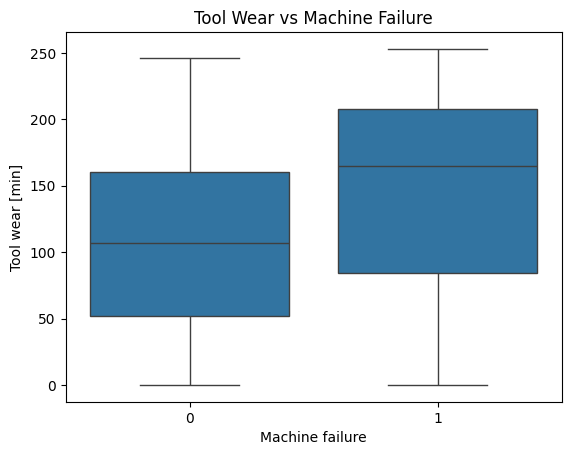

In [135]:
sns.boxplot(
    data=df,
    x="Machine failure",
    y="Tool wear [min]"
)

plt.title("Tool Wear vs Machine Failure")
plt.show()

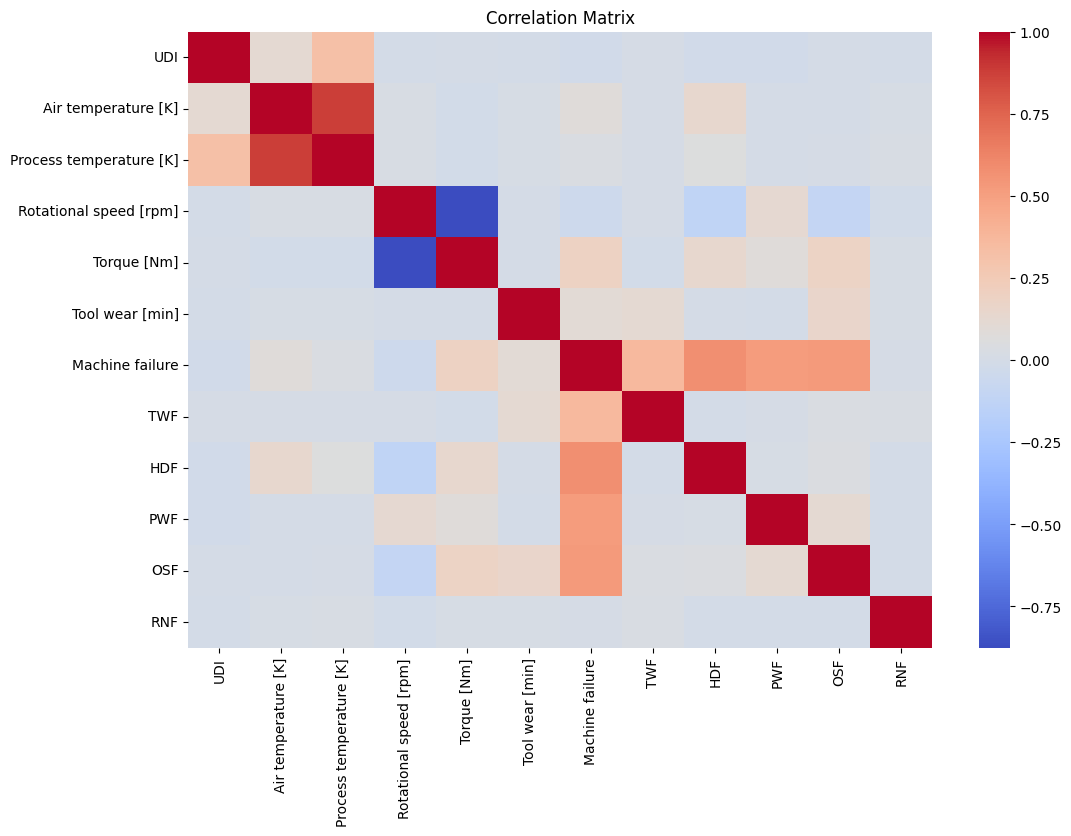

In [136]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [137]:
df_model = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [138]:
df_model["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [139]:
df_model = pd.get_dummies(
    df_model,
    columns=["Type"],
    drop_first=True
)

In [140]:
df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [141]:
X = df_model.drop("Machine failure", axis=1)

y = df_model["Machine failure"]

In [142]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (10000, 7)
y shape: (10000,)

Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


STEP 8 — Train/Test Split

In [143]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 7)
Testing data: (2000, 7)


In [144]:
STEP 9 — Scale the Data

SyntaxError: invalid character '—' (U+2014) (2704152871.py, line 1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

STEP 10 — Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

STEP 11 — Evaluate Logistic Regression

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))
print("F1 Score:", f1_score(y_test, lr_predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_predictions))

Accuracy: 0.8245
Precision: 0.14177215189873418
Recall: 0.8235294117647058
F1 Score: 0.24190064794816415

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



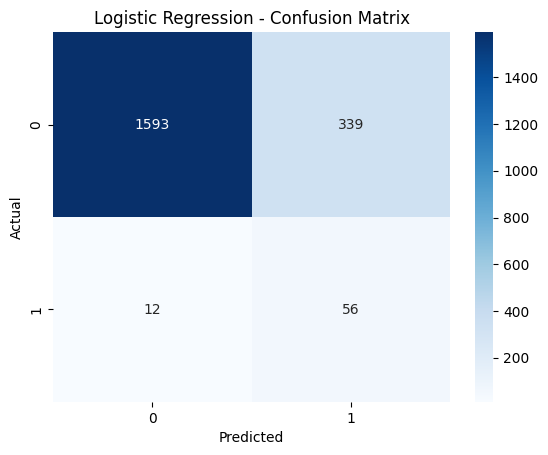

In [ ]:
cm = confusion_matrix(y_test, lr_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

STEP 12 — Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, dt_predictions))
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall:", recall_score(y_test, dt_predictions))
print("F1 Score:", f1_score(y_test, dt_predictions))

Accuracy: 0.9595
Precision: 0.44036697247706424
Recall: 0.7058823529411765
F1 Score: 0.5423728813559322


STEP 13 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1 Score:", f1_score(y_test, rf_predictions))

Accuracy: 0.9815
Precision: 0.918918918918919
Recall: 0.5
F1 Score: 0.6476190476190476


STEP 14 — Compare All Models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    
    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions)
    ],
    
    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions)
    ],
    
    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8245,0.141772,0.823529,0.241901
1,Decision Tree,0.9595,0.440367,0.705882,0.542373
2,Random Forest,0.9815,0.918919,0.500000,0.647619


STEP 16 — Deep Learning: Autoencoder

STEP 16.1 — Import PyTorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.12.0+cpu
GPU available: False


STEP 16.2 — Train Autoencoder Only on Normal Data

In [ ]:
X_normal = X[y == 0]

print("Normal samples:", len(X_normal))
print("Failure samples:", (y == 1).sum())

Normal samples: 9661
Failure samples: 339


In [ ]:
from sklearn.model_selection import train_test_split

X_normal_train, X_normal_test = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

STEP 16.3 — Scale the Data

In [ ]:
from sklearn.preprocessing import StandardScaler

ae_scaler = StandardScaler()

X_normal_train_scaled = ae_scaler.fit_transform(X_normal_train)

X_normal_test_scaled = ae_scaler.transform(X_normal_test)

X_all_scaled = ae_scaler.transform(X)

STEP 17 — Convert Data to PyTorch Tensors

In [ ]:
X_train_tensor = torch.tensor(
    X_normal_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_normal_test_scaled,
    dtype=torch.float32
)

X_all_tensor = torch.tensor(
    X_all_scaled,
    dtype=torch.float32
)

print(X_train_tensor.shape)

torch.Size([7728, 7])


STEP 18 — Create the Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    
    def forward(self, x):
        
        encoded = self.encoder(x)
        
        decoded = self.decoder(encoded)
        
        return decoded

STEP 19 — Initialize the Model

In [ ]:
input_dim = X_train_tensor.shape[1]

model = Autoencoder(input_dim)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=7, bias=True)
  )
)


STEP 20 — Train the Autoencoder

In [ ]:
num_epochs = 50

train_losses = []

model.train()

for epoch in range(num_epochs):
    
    optimizer.zero_grad()
    
    reconstructed = model(X_train_tensor)
    
    loss = criterion(
        reconstructed,
        X_train_tensor
    )
    
    loss.backward()
    
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Loss: {loss.item():.6f}"
        )

Epoch [10/50], Loss: 1.016423
Epoch [20/50], Loss: 1.009182
Epoch [30/50], Loss: 1.001432
Epoch [40/50], Loss: 0.991938
Epoch [50/50], Loss: 0.979175


STEP 21 — Plot Training Loss

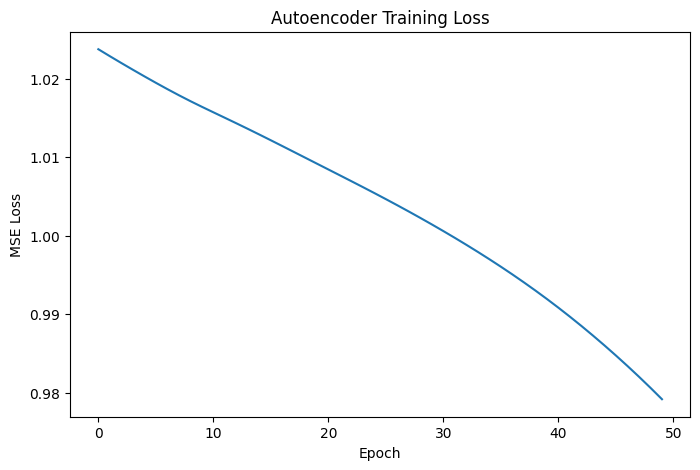

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

STEP 22 — Calculate Reconstruction Error

In [ ]:
model.eval()

with torch.no_grad():
    
    reconstructed_data = model(X_all_tensor)
    
    reconstruction_errors = torch.mean(
        (X_all_tensor - reconstructed_data) ** 2,
        dim=1
    ).numpy()

In [ ]:
results_ae = pd.DataFrame({
    "Reconstruction Error": reconstruction_errors,
    "Actual Failure": y.values
})

results_ae.head()

,Reconstruction Error,Actual Failure
0,1.089100,0
1,0.986505,0
2,1.028699,0
3,0.874609,0
4,0.870740,0


STEP 23 — Compare Normal vs Failure Errors

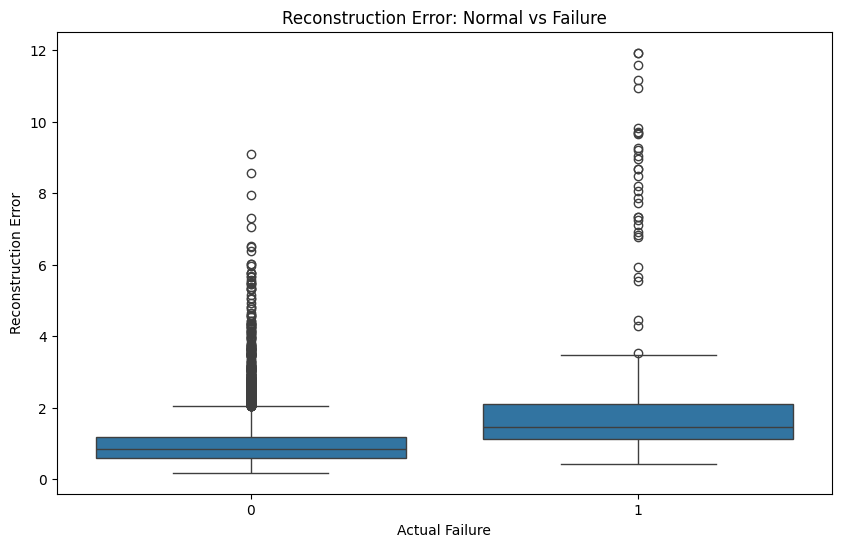

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=results_ae,
    x="Actual Failure",
    y="Reconstruction Error"
)

plt.title("Reconstruction Error: Normal vs Failure")

plt.show()

STEP 24 — Set Anomaly Threshold

In [ ]:
normal_errors = results_ae[
    results_ae["Actual Failure"] == 0
]["Reconstruction Error"]

threshold = np.percentile(
    normal_errors,
    95
)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 2.0008647


STEP 25 — Predict Anomalies

In [ ]:
ae_predictions = (
    reconstruction_errors > threshold
).astype(int)

print(
    classification_report(
        y,
        ae_predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      9661
           1       0.16      0.28      0.21       339

    accuracy                           0.93     10000
   macro avg       0.57      0.62      0.58     10000
weighted avg       0.95      0.93      0.94     10000



STEP 26 — Autoencoder Confusion Matrix

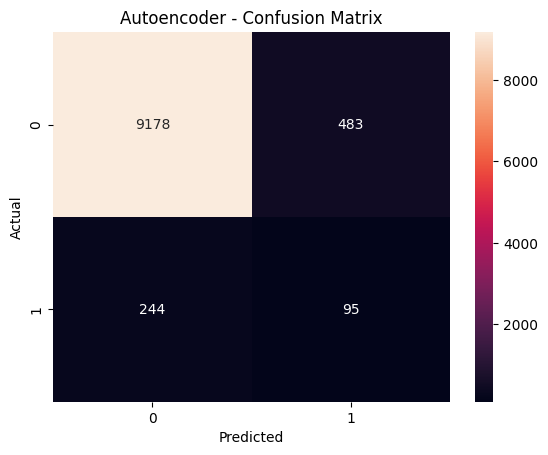

In [ ]:
cm_ae = confusion_matrix(
    y,
    ae_predictions
)

sns.heatmap(
    cm_ae,
    annot=True,
    fmt="d"
)

plt.title(
    "Autoencoder - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

STEP 27 — Evaluate Autoencoder Properly

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Autoencoder Results")
print("-" * 30)

print("Accuracy:", accuracy_score(y, ae_predictions))
print("Precision:", precision_score(y, ae_predictions))
print("Recall:", recall_score(y, ae_predictions))
print("F1 Score:", f1_score(y, ae_predictions))

Autoencoder Results
------------------------------
Accuracy: 0.9273
Precision: 0.1643598615916955
Recall: 0.28023598820059
F1 Score: 0.20719738276990185


ROC-AUC for Autoencoder

Use reconstruction error as the anomaly score:

In [ ]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y,
        reconstruction_errors
    )
)

ROC-AUC: 0.810555104166953


STEP 28 — Create Final Model Comparison

First calculate Autoencoder metrics:

In [ ]:
ae_accuracy = accuracy_score(y, ae_predictions)
ae_precision = precision_score(y, ae_predictions)
ae_recall = recall_score(y, ae_predictions)
ae_f1 = f1_score(y, ae_predictions)
ae_roc_auc = roc_auc_score(y, reconstruction_errors)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Autoencoder"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        ae_accuracy
    ],
    
    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions),
        ae_precision
    ],
    
    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions),
        ae_recall
    ],
    
    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions),
        ae_f1
    ],
    
    "ROC-AUC": [
        roc_auc_score(
            y_test,
            lr_model.predict_proba(X_test_scaled)[:, 1]
        ),
        roc_auc_score(
            y_test,
            dt_model.predict_proba(X_test)[:, 1]
        ),
        roc_auc_score(
            y_test,
            rf_model.predict_proba(X_test)[:, 1]
        ),
        ae_roc_auc
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.824,0.142,0.824,0.242,0.907
1,Decision Tree,0.960,0.440,0.706,0.542,0.846
2,Random Forest,0.982,0.919,0.500,0.648,0.960
3,Autoencoder,0.927,0.164,0.280,0.207,0.811


STEP 29 — Find the Best Model

For predictive maintenance, Recall and F1-score are very important.

In [ ]:
comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.9815,0.918919,0.500000,0.647619,0.960411
1,Decision Tree,0.9595,0.440367,0.705882,0.542373,0.845923
0,Logistic Regression,0.8245,0.141772,0.823529,0.241901,0.906954
3,Autoencoder,0.9273,0.164360,0.280236,0.207197,0.810555


STEP 30 — Feature Importance

This helps explain why the Random Forest predicts failure.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Torque [Nm],0.317731
2,Rotational speed [rpm],0.286996
4,Tool wear [min],0.206195
0,Air temperature [K],0.104718
1,Process temperature [K],0.067570
5,Type_L,0.009502
6,Type_M,0.007288


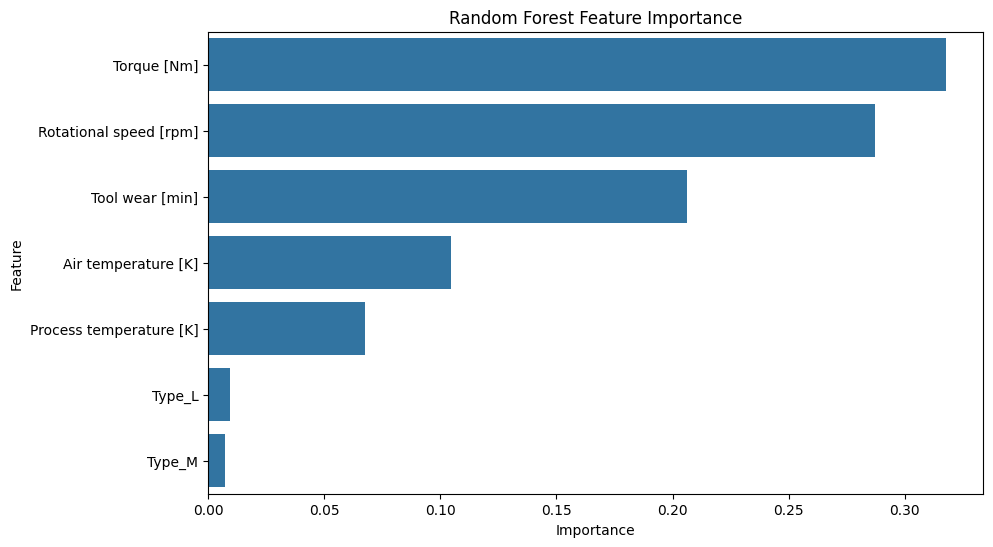

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

Save Random Forest and Scaler

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Models saved successfully!")

Models saved successfully!


Save the Autoencoder

In [ ]:
torch.save(
    model.state_dict(),
    "../models/autoencoder.pth"
)

joblib.dump(
    ae_scaler,
    "../models/autoencoder_scaler.pkl"
)

print("Autoencoder saved successfully!")

Autoencoder saved successfully!


STEP 32 — Create a Simple Prediction Function

In [ ]:
def predict_machine_failure(
    air_temp,
    process_temp,
    rotational_speed,
    torque,
    tool_wear,
    product_type
):
    
    input_data = pd.DataFrame(
        [[
            air_temp,
            process_temp,
            rotational_speed,
            torque,
            tool_wear
        ]],
        columns=[
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]"
        ]
    )
    
    # Add product type
    input_data["Type_L"] = 0
    input_data["Type_M"] = 0
    
    if product_type == "L":
        input_data["Type_L"] = 1
    
    elif product_type == "M":
        input_data["Type_M"] = 1
    
    # Ensure correct column order
    input_data = input_data[X.columns]
    
    # Scale
    input_scaled = scaler.transform(input_data)
    
    # Predict
    probability = rf_model.predict_proba(
        input_scaled
    )[0][1]
    
    prediction = (
        1 if probability >= 0.5 else 0
    )
    
    return prediction, probability

In [ ]:
probability = rf_model.predict_proba(
    input_data
)[0][1]

NameError: name 'input_data' is not defined

In [145]:
def predict_machine_failure(
    air_temp,
    process_temp,
    rotational_speed,
    torque,
    tool_wear,
    product_type
):
    
    input_data = pd.DataFrame(
        [[
            air_temp,
            process_temp,
            rotational_speed,
            torque,
            tool_wear
        ]],
        columns=[
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]"
        ]
    )

    input_data["Type_L"] = 0
    input_data["Type_M"] = 0

    if product_type == "L":
        input_data["Type_L"] = 1
    elif product_type == "M":
        input_data["Type_M"] = 1

    input_data = input_data[X.columns]

    probability = rf_model.predict_proba(
        input_data
    )[0][1]

    prediction = int(probability >= 0.5)

    return prediction, probability

STEP 33 — Test the Prediction Function

Use real sample values:

In [146]:
prediction, probability = predict_machine_failure(
    air_temp=298.1,
    process_temp=308.6,
    rotational_speed=1551,
    torque=42.8,
    tool_wear=0,
    product_type="M"
)

print("Prediction:", prediction)
print(
    "Failure Probability:",
    round(probability * 100, 2),
    "%"
)

Prediction: 0
Failure Probability: 0.0 %


In [147]:
import joblib

joblib.dump(
    threshold,
    "../models/anomaly_threshold.pkl"
)

['../models/anomaly_threshold.pkl']

In [148]:
failure_examples = df[df["Machine failure"] == 1]

failure_examples[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Type"
    ]
].head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
50,298.9,309.1,2861,4.6,143,L
69,298.9,309.0,1410,65.7,191,L
77,298.8,308.9,1455,41.3,208,L
160,298.4,308.2,1282,60.7,216,L
161,298.3,308.1,1412,52.3,218,L
